In [1]:
### Imports

from wordcloud import WordCloud
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
### Leitura e configuração do dataframe

df = pd.read_csv('reviews.csv', quotechar='"', encoding='utf-8')

df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['sentiment'] = pd.to_numeric(df['sentiment'], errors='coerce')

# Converte content para string
df['content'] = df['content'].astype(str)

# Converte sentiment para inteiro
df['sentiment'] = df['sentiment'].astype(int)

# Remove linhas sem conteúdo ou sem sentimento
df = df.dropna(subset=['content', 'sentiment'])


In [3]:
### Outras configs

# Nomes dos sentimentos
class_names = ['negative', 'neutral', 'positive']

# Stopwords em português
stopwords_list = ['de', 'para', 'com', 'que', 'uma', 'o', 'a', 'em', 'e',
                  'os', 'as', 'por', 'um', 'não', 'mais', 'muito']

stopwords_wc = set(stopwords_list)   # para WordCloud
stopwords_skl = stopwords_list       # para scikit-learn


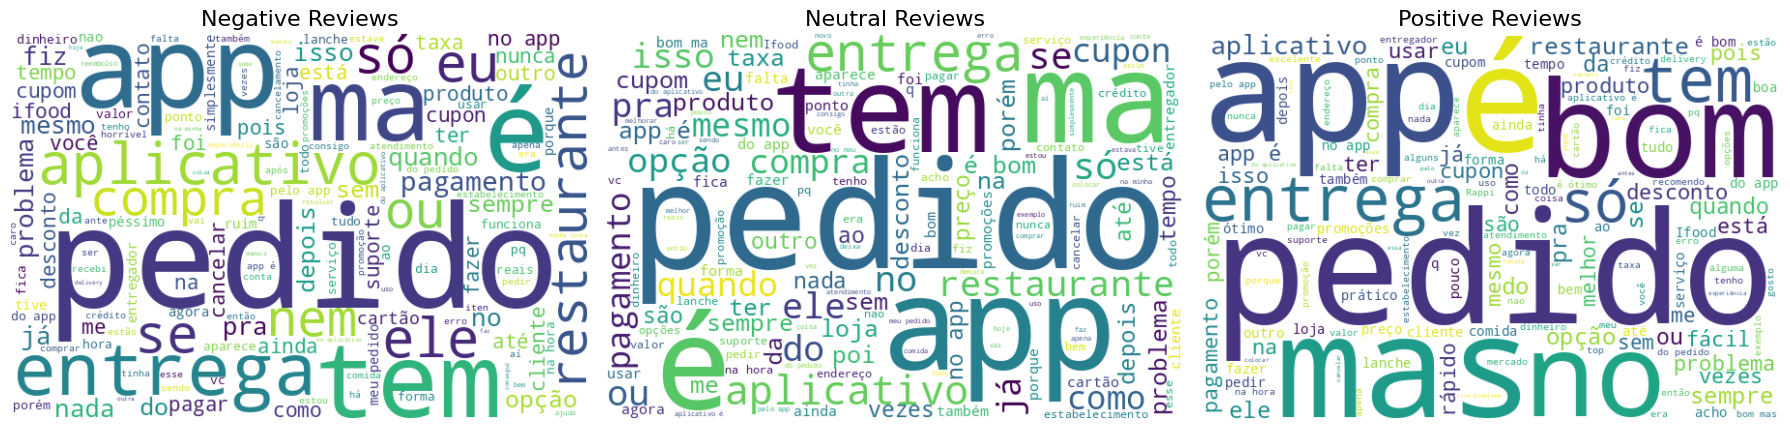

In [4]:
### Nuvens de palavras por sentimento

# Cria figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Gera uma nuvem por sentimento
for i, sentiment_label in enumerate(class_names):
    text = " ".join(df[df['sentiment'] == i]['content'])

    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=150,
        stopwords=stopwords_wc
    ).generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment_label.capitalize()} Reviews', fontsize=16)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [5]:
### Vetorização TF-IDF e divisão treino/teste

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    df['content'], df['sentiment'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=stopwords_skl,
    ngram_range=(1,2)  # unigrams + bigrams
)

# Treina TF-IDF nos dados de treino
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)



In [6]:
### treinamento do modelo regressão logística

#modelo de classificação regressão logística 
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# Previsões no teste
y_pred = clf.predict(X_test_tfidf)


In [7]:
### treinamento do modelo random forest

#modelo de classificação random forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_tfidf, y_train)
#Previsões no teste
y_pred = clf.predict(X_test_tfidf)

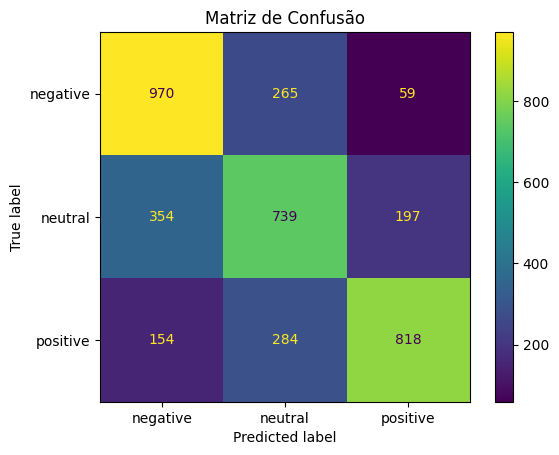

              precision    recall  f1-score   support

    negative       0.66      0.75      0.70      1294
     neutral       0.57      0.57      0.57      1290
    positive       0.76      0.65      0.70      1256

    accuracy                           0.66      3840
   macro avg       0.66      0.66      0.66      3840
weighted avg       0.66      0.66      0.66      3840



In [8]:
### Resultados dos testes

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='viridis')
plt.title('Matriz de Confusão')
plt.show()

# Relatório de classificação
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))


In [9]:
### Teste manual do modelo

# Frase de teste e sentimento real
texto_manual = "absolute cinema"
sentimento_real = 'positive'  # valor esperado: 'negative', 'neutral' ou 'positive'

# Previsão do modelo
texto_tfidf = vectorizer.transform([texto_manual])
pred_sentiment = clf.predict(texto_tfidf)[0]
class_names = ['negative', 'neutral', 'positive']
sentimento_predito = class_names[pred_sentiment]

# Comparação e resultado
resultado = "Sucesso" if sentimento_predito == sentimento_real else "Falha"

print(f"Sentimento previsto: {sentimento_predito}")
print(f"Sentimento real: {sentimento_real}")
print(f"Resultado: {resultado}")


Sentimento previsto: positive
Sentimento real: positive
Resultado: Sucesso


In [10]:
### exportar modelos em formato de json
import json
import numpy as np
from sklearn.ensemble import RandomForestClassifier
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)
if 'vectorizer' not in globals():
    raise NameError("vectorizer não encontrado. Execute a célula que treina o TfidfVectorizer antes de exportar.")
if 'clf' not in globals():
    raise NameError("clf não encontrado. Execute a célula que treina o RandomForestClassifier antes de exportar.")
if not isinstance(clf, RandomForestClassifier):
    raise TypeError("clf não é um RandomForestClassifier. Execute a célula de treino do modelo Random Forest antes de exportar.")
feature_names = vectorizer.get_feature_names_out()
idf_values = vectorizer.idf_.tolist() if hasattr(vectorizer, 'idf_') else None
label_mapping = {str(index): int(label) for index, label in enumerate(clf.classes_)}
reverse_mapping = {str(int(label)): str(index) for index, label in enumerate(clf.classes_)}
estimators_payload = []
for estimator in clf.estimators_:
    tree = estimator.tree_
    estimators_payload.append({
        'children_left': tree.children_left.tolist(),
        'children_right': tree.children_right.tolist(),
        'feature': tree.feature.tolist(),
        'threshold': tree.threshold.tolist(),
        'value': tree.value[:, 0, :].tolist()
    })
export_payload = {
    'model_type': 'random_forest',
    'vocabulary': feature_names.tolist(),
    'idf_values': idf_values,
    'max_features': int(vectorizer.max_features) if vectorizer.max_features is not None else None,
    'ngram_range': list(vectorizer.ngram_range),
    'stop_words': list(getattr(vectorizer, 'stop_words_', stopwords_skl)),
    'classes': clf.classes_.tolist(),
    'label_mapping': label_mapping,
    'reverse_mapping': reverse_mapping,
    'n_estimators': clf.n_estimators,
    'estimators': estimators_payload
}
output_path = 'sentiment_random_forest.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(export_payload, f, cls=NumpyEncoder)
print(f"Modelo Random Forest exportado para {output_path}")

Modelo Random Forest exportado para sentiment_random_forest.json
